# Phase 7 — Core Forecasting Models (Use Case 1)

**เป้าหมาย:** สร้างและเทียบโมเดลพยากรณ์ 5 แบบ เพื่อหาว่าแบบไหนเหมาะกับข้อมูล panel นี้ที่สุด:

1. **สถิติคลาสสิก (ETS / Holt-Winters)** — เทรนแยกทีละ series (เฉพาะ top-5 series ที่ขายดีสุด เพราะเทรนทีละ series ทั้ง 270 series ไม่คุ้มเวลา)
2. **Local per-SKU LightGBM** — เทรนแยกโมเดลต่อ 1 SKU (รวมทุก channel/region ของ SKU นั้น) — 30 โมเดล
3. **Global pooled LightGBM** — เทรนโมเดลเดียวจากทุก SKU/channel/region พร้อมกัน
4. **Global pooled XGBoost** — เหมือนข้อ 3 ในแง่ข้อมูล, feature set, global pooling และ walk-forward folds แต่ใช้ configuration ของ XGBoost ที่กำหนดไว้ในโปรเจกต์ เพื่อเป็น challenger model สำหรับ robustness comparison กับ LightGBM
5. **Global pooled Random Forest** — เหมือนข้อ 3 ในแง่ data/feature/pooling/folds แต่ใช้ `sklearn.RandomForestRegressor` (bagging แทน boosting) เพื่อเป็น challenger model อีกตัวบน library axis เดียวกับ XGBoost

ทุกโมเดลประเมินด้วย **walk-forward CV folds ชุดเดียวกับ Phase 6** เพื่อเทียบกับ baseline ได้ตรงไปตรงมา

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from splits.walk_forward import WalkForwardSplitter
from models.forecast import prepare_categoricals, fit_predict_lgb, fit_predict_xgb, fit_predict_rf, fit_predict_local_per_sku, fit_lgb, ALL_FEATURE_COLS
from models.metrics import score_all

pd.set_option('display.width', 160)

df = pd.read_csv('../data/processed/weekly_features.csv', parse_dates=['week'])
dfc = prepare_categoricals(df)

splitter = WalkForwardSplitter(initial_train_end='2023-09-30', val_fold_weeks=8, final_test_weeks=10)
folds, final_test_weeks = splitter.get_folds(dfc)
print(f'{len(folds)} CV folds, final holdout = {len(final_test_weeks)} weeks (untouched until Phase 13)')

7 CV folds, final holdout = 10 weeks (untouched until Phase 13)


## 1. Global Pooled LightGBM

โมเดลเดียวเทรนจากข้อมูลทุก SKU × channel × region พร้อมกัน ใช้ทุกฟีเจอร์ที่มี (`ALL_FEATURE_COLS` ใน `src/models/forecast.py`) — categorical features (`sku`, `channel`, `region`, `category`, `segment`, `brand`, `lifecycle_stage`) ใช้ LightGBM's native categorical handling ไม่ต้อง one-hot encode


In [2]:
fold_scores_global = []
n_negative_preds = 0
n_total_preds = 0
for f in folds:
    train = dfc[dfc.week.isin(f.train_weeks)]
    val = dfc[dfc.week.isin(f.val_weeks)]
    pred = fit_predict_lgb(train, val)
    n_negative_preds += int((pred < 0).sum())
    n_total_preds += len(pred)
    fold_scores_global.append(score_all(val.target_next_week.values, pred))

global_cv = {k: np.mean([s[k] for s in fold_scores_global]) for k in fold_scores_global[0]}
print('Global pooled LightGBM, CV average:')
print({k: round(v, 3) for k, v in global_cv.items()})
print(f'Negative predictions: {n_negative_preds} / {n_total_preds} ({n_negative_preds / n_total_preds:.3%}) — units_sold cannot be negative in reality, and the model has no floor at 0')


Global pooled LightGBM, CV average:
{'MAE': np.float64(25.169), 'RMSE': np.float64(32.263), 'WAPE': np.float64(0.224), 'SMAPE': np.float64(0.228)}
Negative predictions: 0 / 14850 (0.000%) — units_sold cannot be negative in reality, and the model has no floor at 0


## 2. Global Pooled XGBoost

โมเดลเดียวกับข้อ 1 ในแง่ data/feature (pooled ข้าม SKU × channel × region, ใช้ฟีเจอร์ครบชุดเดียวกัน, categorical column ใช้ native categorical support เหมือนกัน — ไม่ one-hot) รวมถึงใช้ walk-forward validation folds ชุดเดียวกัน แต่ใช้ configuration ของ XGBoost ตามที่กำหนดไว้ในโปรเจกต์ — ตั้งใจใช้เป็น challenger model สำหรับ robustness comparison กับ Global pooled LightGBM เพื่อดูว่าผลลัพธ์ยังใกล้เคียงกันหรือไม่เมื่อเปลี่ยน boosting implementation โดยไม่ได้สมมติว่า configuration ของทั้งสองโมเดลเหมือนกันทุกด้าน

In [3]:
fold_scores_global_xgb = []
for f in folds:
    train = dfc[dfc.week.isin(f.train_weeks)]
    val = dfc[dfc.week.isin(f.val_weeks)]
    pred = fit_predict_xgb(train, val)
    fold_scores_global_xgb.append(score_all(val.target_next_week.values, pred))

global_xgb_cv = {k: np.mean([s[k] for s in fold_scores_global_xgb]) for k in fold_scores_global_xgb[0]}
print('Global pooled XGBoost, CV average:')
print({k: round(v, 3) for k, v in global_xgb_cv.items()})

Global pooled XGBoost, CV average:
{'MAE': np.float64(25.315), 'RMSE': np.float64(32.49), 'WAPE': np.float64(0.225), 'SMAPE': np.float64(0.229)}


## 3. Global Pooled Random Forest

โมเดลเดียวกับข้อ 1-2 ในแง่ data/feature (pooled ข้าม SKU × channel × region, ใช้ฟีเจอร์ครบชุดเดียวกัน) และใช้ walk-forward validation folds ชุดเดียวกัน แต่ใช้ `sklearn.RandomForestRegressor` (bagging แทน boosting) เป็น challenger model อีกตัวบน library axis — ต่างจาก LightGBM/XGBoost ตรงที่ `RandomForestRegressor` ไม่รองรับ pandas categorical dtype โดยตรง จึงต้อง ordinal-encode categorical columns ส่วนค่า `promo_recency` ที่เป็น NaN โดยตั้งใจ (ดู README ส่วน Data) เติมด้วยค่า sentinel นอกช่วงข้อมูลจริงเพื่อให้ต้นไม้แยกแถวเหล่านี้จากค่า recency จริงได้ — เป็นการเลือกเชิงโมเดล ไม่ใช่ข้อจำกัดของไลบรารี (sklearn เวอร์ชันที่ pin ไว้รองรับ NaN โดยตรงอยู่แล้วตั้งแต่ 1.4) แทนที่จะใช้ `make_lgb_frame` เดิม — ดู `make_rf_frame()` ใน `src/models/forecast.py`

In [4]:
fold_scores_global_rf = []
for f in folds:
    train = dfc[dfc.week.isin(f.train_weeks)]
    val = dfc[dfc.week.isin(f.val_weeks)]
    pred = fit_predict_rf(train, val)
    fold_scores_global_rf.append(score_all(val.target_next_week.values, pred))

global_rf_cv = {k: np.mean([s[k] for s in fold_scores_global_rf]) for k in fold_scores_global_rf[0]}
print('Global pooled Random Forest, CV average:')
print({k: round(v, 3) for k, v in global_rf_cv.items()})

Global pooled Random Forest, CV average:
{'MAE': np.float64(25.235), 'RMSE': np.float64(32.307), 'WAPE': np.float64(0.224), 'SMAPE': np.float64(0.229)}


### เปรียบเทียบ WAPE ราย Walk-forward Fold

ตารางต่อไปใช้ผลที่คำนวณไว้แล้วใน `fold_scores_global`, `fold_scores_global_xgb` และ `fold_scores_global_rf` เพื่อดูว่าความใกล้เคียงของ WAPE เกิดสม่ำเสมอเพียงใดในทั้ง 7 folds โดยไม่ retrain หรือเปลี่ยน configuration ของโมเดล พร้อมทดสอบนัยสำคัญทางสถิติ (paired t-test ข้าม fold) ของ Global pooled LightGBM (โมเดลหลัก) เทียบกับ challenger ทั้งสองตัวแยกกัน — LightGBM vs XGBoost และ LightGBM vs Random Forest — พร้อมปรับ p-value ด้วย Holm correction เพราะทดสอบ 2 คู่พร้อมกัน (ไม่ใช่แค่เลือกคู่ที่ WAPE เฉลี่ยต่ำสุด 2 อันดับแรกมาทดสอบคู่เดียว ซึ่งไม่จำเป็นต้องเป็นคู่ที่ใกล้กันที่สุดจริงๆ เมื่อมี 3 โมเดล) เพื่อแยกว่าความแตกต่างเป็นสัญญาณจริงหรือ noise จากการเทรนซ้ำ

In [5]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

fold_wape_comparison = pd.DataFrame({
    'fold': np.arange(1, len(fold_scores_global) + 1),
    'LightGBM_WAPE': [score['WAPE'] for score in fold_scores_global],
    'XGBoost_WAPE': [score['WAPE'] for score in fold_scores_global_xgb],
    'RandomForest_WAPE': [score['WAPE'] for score in fold_scores_global_rf],
})

fold_wape_summary = pd.DataFrame({
    'model': ['Global pooled LightGBM', 'Global pooled XGBoost', 'Global pooled Random Forest'],
    'mean_WAPE': [
        fold_wape_comparison['LightGBM_WAPE'].mean(),
        fold_wape_comparison['XGBoost_WAPE'].mean(),
        fold_wape_comparison['RandomForest_WAPE'].mean(),
    ],
    'std_WAPE': [
        fold_wape_comparison['LightGBM_WAPE'].std(ddof=1),
        fold_wape_comparison['XGBoost_WAPE'].std(ddof=1),
        fold_wape_comparison['RandomForest_WAPE'].std(ddof=1),
    ],
}).sort_values('mean_WAPE').reset_index(drop=True)

display(fold_wape_comparison.round(4))
display(fold_wape_summary.round(4))

# LightGBM is the primary model (lowest mean WAPE) -- test it against BOTH challengers
# explicitly instead of picking "the two lowest-mean models" and calling that pair the
# closest-scoring one. With 3 models those aren't the same thing: the two lowest by
# value need not be the two whose means are nearest each other (an earlier version of
# this cell used sort_values().head(2), which silently mislabeled the LightGBM/XGBoost
# pair as "closest" in at least one run where LightGBM/RandomForest actually were).
# Testing both challengers means two hypothesis tests instead of one, so Holm
# correction is applied across their p-values to control the combined false-positive
# rate; the reported n reflects fold-pairs, held equal across both comparisons here
# since every fold has a score for all three models.
n_folds = len(fold_wape_comparison)
comparisons = [
    ('Global pooled LightGBM', 'Global pooled XGBoost', 'LightGBM_WAPE', 'XGBoost_WAPE'),
    ('Global pooled LightGBM', 'Global pooled Random Forest', 'LightGBM_WAPE', 'RandomForest_WAPE'),
]

rows = []
for name_a, name_b, col_a, col_b in comparisons:
    a = fold_wape_comparison[col_a].to_numpy()
    b = fold_wape_comparison[col_b].to_numpy()
    diff = a - b  # negative => LightGBM (a) scores lower/better than the challenger (b)
    t_stat, p_value = stats.ttest_rel(a, b)
    se = diff.std(ddof=1) / np.sqrt(n_folds)
    ci_low, ci_high = stats.t.interval(0.95, df=n_folds - 1, loc=diff.mean(), scale=se)
    rows.append({
        'comparison': f'{name_a} vs {name_b}',
        'mean_diff_WAPE': diff.mean(),
        'ci95_low': ci_low,
        'ci95_high': ci_high,
        't_stat': t_stat,
        'p_value': p_value,
    })

significance_df = pd.DataFrame(rows)
reject, p_holm, _, _ = multipletests(significance_df['p_value'], method='holm', alpha=0.05)
significance_df['p_value_holm'] = p_holm
significance_df['significant_at_0.05'] = reject
display(significance_df.round(4))

for _, row in significance_df.iterrows():
    verdict = 'a significant difference WAS detected' if row['significant_at_0.05'] else 'no significant difference was detected'
    print(
        f"{row['comparison']} (n={n_folds} folds): mean WAPE diff = {row['mean_diff_WAPE']:.4f} "
        f"[95% CI {row['ci95_low']:.4f}, {row['ci95_high']:.4f}], "
        f"raw p={row['p_value']:.3f}, Holm-adjusted p={row['p_value_holm']:.3f} -- {verdict}"
    )


,fold,LightGBM_WAPE,XGBoost_WAPE,RandomForest_WAPE
0,1,0.2316,0.2377,0.2285
1,2,0.2319,0.2338,0.2303
2,3,0.2194,0.2200,0.2220
3,4,0.2242,0.2247,0.2237
4,5,0.2200,0.2195,0.2193
5,6,0.2172,0.2186,0.2213
6,7,0.2203,0.2201,0.2235


,model,mean_WAPE,std_WAPE
0,Global pooled LightGBM,0.2235,0.0060
1,Global pooled Random Forest,0.2241,0.0039
2,Global pooled XGBoost,0.2249,0.0077


,comparison,mean_diff_WAPE,ci95_low,ci95_high,t_stat,p_value,p_value_holm,significant_at_0.05
0,Global pooled LightGBM vs Global pooled XGBoost,-0.0014,-0.0035,0.0007,-1.6573,0.1485,0.2971,False
1,Global pooled LightGBM vs Global pooled Random...,-0.0006,-0.0031,0.0020,-0.5441,0.6060,0.6060,False


Global pooled LightGBM vs Global pooled XGBoost (n=7 folds): mean WAPE diff = -0.0014 [95% CI -0.0035, 0.0007], raw p=0.149, Holm-adjusted p=0.297 -- no significant difference was detected
Global pooled LightGBM vs Global pooled Random Forest (n=7 folds): mean WAPE diff = -0.0006 [95% CI -0.0031, 0.0020], raw p=0.606, Holm-adjusted p=0.606 -- no significant difference was detected


**ผลลัพธ์:** ตาราง `fold_wape_summary` ด้านบนแสดง WAPE เฉลี่ยที่ใกล้เคียงกันมากทั้ง 3 libraries — LightGBM 0.2235, Random Forest 0.2241, XGBoost 0.2249 (std dev ราย fold 0.0039–0.0077) — paired t-test ของ LightGBM เทียบกับ challenger ทั้งสองตัวแยกกัน (Holm-corrected เพราะทดสอบ 2 คู่พร้อมกัน) ให้ p = 0.297 (vs XGBoost) และ p = 0.606 (vs Random Forest) ไม่พบความแตกต่างที่มีนัยสำคัญทางสถิติกับทั้งคู่ที่ระดับ 0.05 — สอดคล้องกับการอธิบายว่าความต่างของค่าเฉลี่ยเล็กน้อยนี้อาจมาจาก fold-to-fold noise ไม่ใช่สัญญาณจริง (การไม่ reject H0 ไม่ใช่หลักฐานว่าไม่มีความต่างเลย เพียงแต่ข้อมูล 7 folds ไม่พอสรุปว่าต่างอย่างมีนัยสำคัญ) ขณะที่ความแตกต่างระหว่าง Global pooled และ Local per-SKU LightGBM (ข้อ 4 ด้านล่าง, WAPE 0.257 vs 0.224) มีขนาดใหญ่กว่าอย่างชัดเจน ผลนี้จึงบ่งชี้ว่า pooling strategy มีผลต่อ performance มากกว่าความแตกต่างระหว่าง library ที่ใช้ (boosting หรือ bagging) สำหรับการทดลองชุดนี้ โดยไม่ได้อ้างนัยสำคัญทางสถิติเกินกว่าที่ทดสอบจริงหรือสรุปเป็นกฎทั่วไป

## 4. Local Per-SKU LightGBM

เทรนแยกโมเดลต่อ SKU (30 โมเดล, รวม channel/region ของ SKU นั้นเป็น training data เดียว) — ทดสอบสมมติฐานว่าการ pool ข้อมูลข้าม SKU (global model) ช่วยจริงหรือไม่ เทียบกับการให้แต่ละ SKU มีโมเดลเฉพาะตัว

In [6]:
fold_scores_local = []
n_negative_preds_local = 0
n_total_preds_local = 0
for f in folds:
    train = dfc[dfc.week.isin(f.train_weeks)]
    val = dfc[dfc.week.isin(f.val_weeks)]
    pred = fit_predict_local_per_sku(train, val)
    mask = ~np.isnan(pred)
    n_negative_preds_local += int((pred[mask] < 0).sum())
    n_total_preds_local += int(mask.sum())
    fold_scores_local.append(score_all(val.target_next_week.values[mask], pred[mask]))

local_cv = {k: np.mean([s[k] for s in fold_scores_local]) for k in fold_scores_local[0]}
print('Local per-SKU LightGBM, CV average:')
print({k: round(v, 3) for k, v in local_cv.items()})
print(f'Negative predictions: {n_negative_preds_local} / {n_total_preds_local} ({n_negative_preds_local / n_total_preds_local:.3%})')


Local per-SKU LightGBM, CV average:
{'MAE': np.float64(28.824), 'RMSE': np.float64(36.845), 'WAPE': np.float64(0.257), 'SMAPE': np.float64(0.257)}
Negative predictions: 0 / 14850 (0.000%)


**ผลลัพธ์:** Global pooled LightGBM (WAPE ต่ำกว่า) ชนะ local per-SKU LightGBM — ยืนยันสมมติฐานว่าการแบ่งปันข้อมูลข้าม SKU ช่วยได้จริง โดยเฉพาะกับ SKU ที่มีประวัติสั้นหรือขายไม่บ่อย ซึ่งโมเดลแยกต่อ SKU มีข้อมูลไม่พอเรียนรู้ pattern ที่ดี (การทดลองนี้เทียบเฉพาะ pooling axis ด้วย LightGBM ตัวเดียว — ดูข้อ 2-3 ด้านบนสำหรับ library axis)

## 5. Controlled Comparison: ETS vs. Global LightGBM (Top-5 Series)

เทรน SARIMA/ETS แยกทีละ series ทั้ง 270 series ไม่คุ้มเวลาและข้อมูลบาง series สั้นเกินไปสำหรับ seasonal ETS (ต้องการอย่างน้อย ~2 รอบฤดูกาล) จึงเลือกทำเฉพาะ **5 series ที่ขายรวมสูงสุด** เป็นตัวแทน แล้วเทียบกับ Global LightGBM **บน series ชุดเดียวกันเท่านั้น** เพื่อให้เทียบกันแบบยุติธรรม (ไม่ใช่เทียบ WAPE ข้าม scope ที่ต่างกัน)

In [7]:
top_series = df.groupby(['sku', 'channel', 'region']).units_sold.sum().sort_values(ascending=False).head(5)
print('Top-5 series by total units_sold:')
print(top_series)


Top-5 series by total units_sold:
sku     channel   region  
YO-029  Retail    PL-South    19861
                  PL-North    19819
YO-005  Retail    PL-North    19543
        Discount  PL-North    19537
                  PL-South    19514
Name: units_sold, dtype: int64


In [8]:
ets_scores = []
lgb_on_top5_scores = []

for f in folds:
    train = dfc[dfc.week.isin(f.train_weeks)]
    val_all = dfc[dfc.week.isin(f.val_weeks)]
    pred_all = fit_predict_lgb(train, val_all)
    val_all = val_all.assign(pred=pred_all)
    for (sku, ch, rg) in top_series.index:
        sub = val_all[(val_all.sku == sku) & (val_all.channel == ch) & (val_all.region == rg)]
        if len(sub):
            lgb_on_top5_scores.append(score_all(sub.target_next_week.values, sub.pred.values))

for (sku, ch, rg) in top_series.index:
    series_df = df[(df.sku == sku) & (df.channel == ch) & (df.region == rg)].sort_values('week').set_index('week')
    series_df.index = pd.DatetimeIndex(series_df.index)
    for f in folds:
        train_s = series_df[series_df.index.isin(f.train_weeks)]['units_sold'].asfreq('W-MON')
        val_s = series_df[series_df.index.isin(f.val_weeks)]
        if len(train_s) < 30 or len(val_s) == 0:
            continue
        try:
            model = ExponentialSmoothing(
                train_s, trend='add', seasonal='add', seasonal_periods=52, initialization_method='estimated'
            ).fit()
            fc = model.forecast(len(val_s))
            fc.index = val_s.index
        except Exception:
            continue
        actual = val_s['target_next_week'].values
        pred = fc.values
        mask = ~np.isnan(actual)
        if mask.sum() == 0:
            continue
        ets_scores.append(score_all(actual[mask], pred[mask]))

ets_cv = {k: np.mean([s[k] for s in ets_scores]) for k in ets_scores[0]}
lgb_top5_cv = {k: np.mean([s[k] for s in lgb_on_top5_scores]) for k in lgb_on_top5_scores[0]}
print('ETS (Holt-Winters), top-5 series, CV average:')
print({k: round(v, 3) for k, v in ets_cv.items()})
print('Global LightGBM, SAME top-5 series, CV average:')
print({k: round(v, 3) for k, v in lgb_top5_cv.items()})

top5_controlled_comparison = pd.DataFrame([
    {'model': 'ETS (Holt-Winters)', **ets_cv},
    {'model': 'Global LightGBM (same top-5 series)', **lgb_top5_cv},
]).sort_values('WAPE').reset_index(drop=True)
top5_controlled_comparison.round(3)


ETS (Holt-Winters), top-5 series, CV average:
{'MAE': np.float64(39.13), 'RMSE': np.float64(47.438), 'WAPE': np.float64(0.301), 'SMAPE': np.float64(0.292)}
Global LightGBM, SAME top-5 series, CV average:
{'MAE': np.float64(28.444), 'RMSE': np.float64(35.022), 'WAPE': np.float64(0.214), 'SMAPE': np.float64(0.216)}


,model,MAE,RMSE,WAPE,SMAPE
0,Global LightGBM (same top-5 series),28.444,35.022,0.214,0.216
1,ETS (Holt-Winters),39.130,47.438,0.301,0.292


**ผลลัพธ์:** แม้เทียบเฉพาะ 5 series ที่มีข้อมูลยาวและสม่ำเสมอที่สุด (เหมาะกับ ETS ที่สุดแล้ว) LightGBM ก็ยังชนะ ETS — เพราะ ETS ใช้แค่ประวัติของ series ตัวเองในการพยากรณ์ ในขณะที่ LightGBM ใช้ทั้งประวัติของ series นั้น **และ** ข้อมูลบริบท (ราคา โปรโมชัน ฤดูกาล enrichment) ที่ ETS ไม่รองรับ

ETS ถูกแยกไว้ใน controlled comparison นี้และไม่รวมใน full-panel leaderboard ด้านล่าง เพราะ metric ของ ETS คำนวณจาก top-5 series ซึ่งเป็น evaluation population คนละชุดกับโมเดลใน full-panel comparison การนำมาจัดอันดับร่วมกันจึงไม่ใช่การเปรียบเทียบแบบ apples-to-apples

## 6. Full-panel Leaderboard (รวม Baseline จาก Phase 6)

ตารางนี้รวมเฉพาะโมเดลที่ประเมินใน full-panel CV scope เดียวกัน ส่วน ETS แสดงแยกไว้ใน Controlled Comparison: ETS vs. Global LightGBM (Top-5 Series) ด้านบน

In [9]:
from models.baseline import add_baseline_predictions

dfb = add_baseline_predictions(df)
baseline_rows = []
for name, col in [('Naive', 'pred_naive'), ('Seasonal Naive', 'pred_seasonal_naive'), ('Moving Avg (4w)', 'pred_moving_avg_4')]:
    fold_scores = []
    for f in folds:
        val = dfb[dfb.week.isin(f.val_weeks)].dropna(subset=[col, 'target_next_week'])
        if len(val) == 0:
            continue
        fold_scores.append(score_all(val.target_next_week.values, val[col].values))
    baseline_rows.append({'model': name, **{k: np.mean([s[k] for s in fold_scores]) for k in fold_scores[0]}})

comparison = pd.DataFrame(baseline_rows + [
    {'model': 'Local per-SKU LightGBM', **local_cv},
    {'model': 'Global pooled LightGBM', **global_cv},
    {'model': 'Global pooled XGBoost', **global_xgb_cv},
    {'model': 'Global pooled Random Forest', **global_rf_cv},
])
comparison = comparison.sort_values('WAPE').reset_index(drop=True)
comparison.round(3)

,model,MAE,RMSE,WAPE,SMAPE
0,Global pooled LightGBM,25.169,32.263,0.224,0.228
1,Global pooled Random Forest,25.235,32.307,0.224,0.229
2,Global pooled XGBoost,25.315,32.490,0.225,0.229
3,Moving Avg (4w),27.348,35.134,0.243,0.246
4,Local per-SKU LightGBM,28.824,36.845,0.257,0.257
5,Naive,34.225,43.847,0.304,0.307
6,Seasonal Naive,39.935,51.328,0.356,0.338


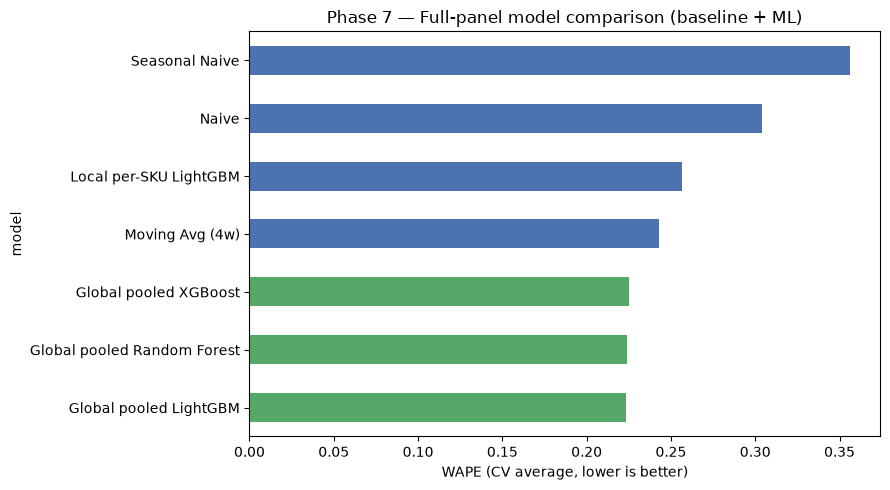

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = comparison.set_index('model')['WAPE'].sort_values()
colors = ['#55A868' if m in ('Global pooled LightGBM', 'Global pooled XGBoost', 'Global pooled Random Forest') else '#4C72B0' for m in plot_df.index]
plot_df.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('WAPE (CV average, lower is better)')
ax.set_title('Phase 7 — Full-panel model comparison (baseline + ML)')
plt.tight_layout()
plt.savefig('../reports/figures/phase7_model_comparison.png', dpi=120)
plt.show()

**สรุป:** ใน full-panel scope เดียวกัน Global pooled LightGBM และ Global pooled Random Forest มี WAPE เท่ากันที่ทศนิยม 3 ตำแหน่ง (0.224 ทั้งคู่) ส่วน Global pooled XGBoost อยู่ที่ 0.225 — ใกล้เคียงกันมากทั้ง 3 โมเดล ขณะที่ความแตกต่างระหว่าง Global pooled และ Local per-SKU LightGBM (0.257) มีขนาดชัดเจนกว่ามาก ภายใต้ configuration ของการทดลองนี้จึงบ่งชี้ว่า pooling strategy มีผลต่อ performance มากกว่าความแตกต่างระหว่าง library (boosting หรือ bagging) โดยยังคงเลือก **Global pooled LightGBM** เป็นโมเดลหลักของโปรเจกต์ เพราะเป็นโมเดลที่ downstream phases ใช้ต่ออยู่แล้ว และไม่พบความแตกต่างที่มีนัยสำคัญทางสถิติกับ challenger ทั้งสองตัวเมื่อทดสอบแยกกัน (paired t-test, Holm-corrected: p = 0.297 vs XGBoost, p = 0.606 vs Random Forest — ดูหัวข้อ 3) ส่วน XGBoost และ Random Forest ทำหน้าที่เป็น challenger models สำหรับ robustness comparison

## 7. Feature Importance ของ Global Model

เทรนโมเดล global บนข้อมูลทั้งหมดก่อนช่วง final holdout (คือ CV ทั้งหมดรวมกัน) เพื่อดู feature importance โดยรวม — ช่วยให้เห็นภาพคร่าวๆ ก่อนวัดผลอย่างเป็นทางการใน Phase 11 (feature ablation) (ใช้ global LightGBM เป็นตัวแทน เพราะเป็นโมเดลที่ carry ต่อไปยัง phase ถัดไป)

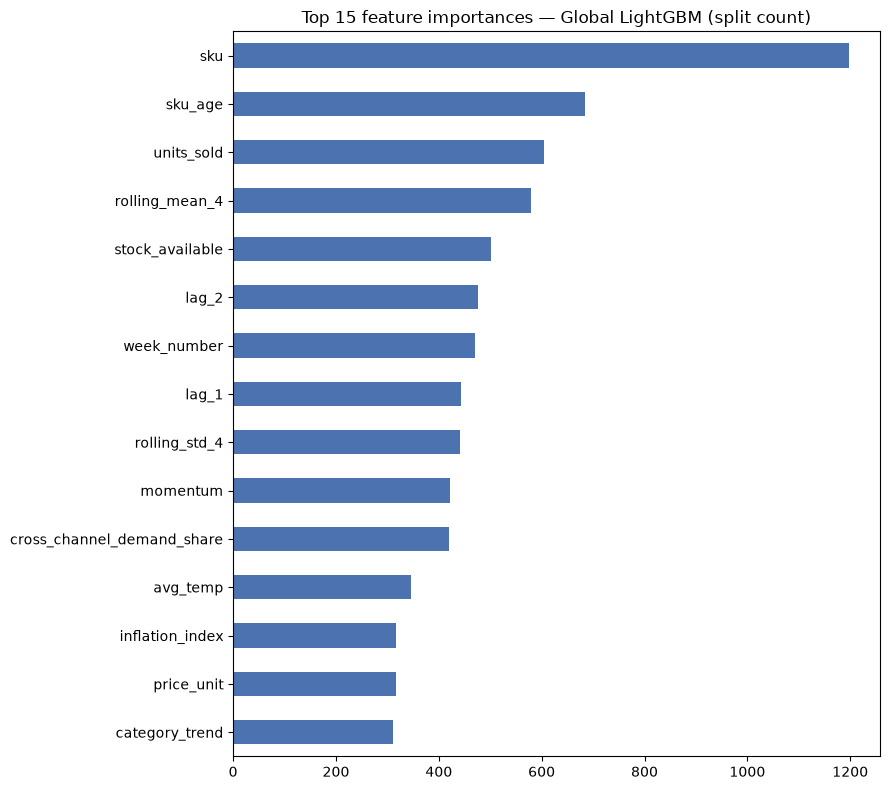

In [11]:
cv_all = dfc[~dfc.week.isin(final_test_weeks)]
full_model = fit_lgb(cv_all)

importance = pd.Series(full_model.feature_importances_, index=ALL_FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
importance.head(15).sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 15 feature importances — Global LightGBM (split count)')
plt.tight_layout()
plt.savefig('../reports/figures/phase7_feature_importance.png', dpi=120)
plt.show()


## 8. สรุป Phase 7

**Full-panel comparison:**
- Leaderboard เปรียบเทียบ Global pooled LightGBM, Global pooled XGBoost, Global pooled Random Forest, Local per-SKU LightGBM, Moving Avg (4w), Naive และ Seasonal Naive บน CV scope เดียวกัน
- Global pooled LightGBM (0.224), Random Forest (0.224) และ XGBoost (0.225) ใกล้เคียงกันมาก (mean_WAPE ต่างกันในหลักทศนิยมที่ 3-4 เท่านั้น)
- ความแตกต่างระหว่าง Global pooled กับ Local per-SKU LightGBM ชัดเจนกว่ามาก (0.224 vs 0.257)
- Paired t-test ของ LightGBM เทียบกับ challenger ทั้งสองตัวแยกกัน (Holm-corrected): **p = 0.297 vs XGBoost, p = 0.606 vs Random Forest** — ไม่พบความแตกต่างที่มีนัยสำคัญทางสถิติกับทั้งคู่ (ดูหัวข้อ 3)
- **สรุป**: pooling strategy มีผลต่อ performance มากกว่าความแตกต่างระหว่าง library ที่ใช้ (boosting หรือ bagging) โดยไม่อ้างว่าเป็นข้อสรุปสากล

**Controlled Comparison (Top-5 Series):**
- ETS / Holt-Winters และ Global LightGBM ถูกเปรียบเทียบบน top-5 series ชุดเดียวกันในตารางแยกต่างหาก
- ETS ไม่อยู่ใน full-panel leaderboard เพราะ evaluation population ต่างกัน

**โมเดลที่เลือกใช้ต่อในโปรเจกต์: Global pooled LightGBM**
- WAPE ใกล้เคียงกับ Global pooled Random Forest ที่ทศนิยม 3 ตำแหน่ง (0.224 ทั้งคู่) และกับ Global pooled XGBoost (0.225)
- ไม่พบความแตกต่างที่มีนัยสำคัญทางสถิติกับ challenger ทั้งสองตัวเมื่อทดสอบแยกกัน (paired t-test, Holm-corrected: p = 0.297 vs XGBoost, p = 0.606 vs Random Forest)
- LightGBM ยังคงถูกเลือกเพราะเป็นโมเดลที่ downstream project phases (10, 11) ใช้ต่ออยู่แล้ว **ไม่ใช่** เพราะแม่นยำกว่าอย่างมีนัยสำคัญ
- XGBoost และ Random Forest ทำหน้าที่เป็น challenger models สำหรับ robustness comparison บน library axis — ไม่ใช่ upper bound หรือเพดานอ้างอิง